# 1). Applying two more Hyper Parameters (BatchSize and Learning Rate)

This is extension to the work done in '02__Keras_CNN_Tuning_Using_Dropout
Thus until Step #7, all code is from file '02__Keras_CNN_Tuning_Using_Dropout
Post Step#7, This code will apply 'Batch Size' and visualize the change
Later apply 'Learning Rate' change and visualize the change

In [1]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop

In [2]:
# Load up our raw data set:

(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = mnist.load_data()

# mnist.load_data() is a function from TensorFlow's Keras API that loads the MNIST dataset, 
# a collection of handwritten digit images (0-9) commonly used for machine learning tasks, especially in deep learning


# 2). Shape and normalize the data:

In [3]:
# Shape and normalize the data:
# Since we're treating the data as 2D images of 28x28 pixels, we need to shape it accordingly. 
# Depending on the data format Keras is set up for, this may be 1x28x28 or 28x28x1 
# (the "1" indicates a single color channel, as this is just grayscale.
# If we were dealing with color images, it would be 3 instead of 1 since we'd have red, green, and blue color channels)


from tensorflow.keras import backend as K

if K.image_data_format() == 'channels_first':
    train_images = mnist_train_images.reshape(mnist_train_images.shape[0], 1, 28, 28)
    test_images = mnist_test_images.reshape(mnist_test_images.shape[0], 1, 28, 28)
    input_shape = (1, 28, 28)
else:
    train_images = mnist_train_images.reshape(mnist_train_images.shape[0], 28, 28, 1)
    test_images = mnist_test_images.reshape(mnist_test_images.shape[0], 28, 28, 1)
    input_shape = (28, 28, 1)
    
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
train_images /= 255
test_images /= 255

# Code Explanation:
# This code prepares image data for use in a convolutional neural network (CNN) with Keras. 
# It first checks the image data format used by the backend (either 'channels_first' or 'channels_last'). 
# This is important because different deep learning frameworks and hardware may expect image data in different formats.

# If the format is 'channels_first', the code reshapes the training and test images to have the channel dimension 
# (for grayscale images, this is 1) as the second dimension, resulting in a shape of (number of images, 1, 28, 28). 
# If the format is 'channels_last', the channel dimension is placed last, giving a shape of (number of images, 28, 28, 1). 
# The variable input_shape is set accordingly, so it can be used when defining the input layer of the model.

# After reshaping, the code converts the image data to 32-bit floating point numbers, 
# which is a common requirement for neural network computations. 
# Finally, it normalizes the pixel values by dividing by 255, scaling them from the original range of 0–255 to a range of 0–1. 
# This normalization helps the neural network train more efficiently and achieve better performance.

# Why Divide by 255 and Normalization here?
# Typical image data (e.g. MNIST, CIFAR, etc.) is stored as 8-bit integers:
# Thus cach pixel has values in the range 0 to 255 (because 8-bit: 2^8 = 256 levels).
# Neural networks (especially deep learning models like CNNs) generally work better when >
# Inputs are scaled to a small, consistent range — most often between 0 and 1
# So normalized_pixel = original_pixel / 255.0
# converts all pixel values from 0-255 → 0.0-1.0 

# 3). Convert Train and Test Labels in one-hot format:

In [4]:
# Convert our train and test labels to be categorical in one-hot format:

train_labels = tensorflow.keras.utils.to_categorical(mnist_train_labels, 10)
test_labels = tensorflow.keras.utils.to_categorical(mnist_test_labels, 10)

# This code converts the training and test labels from integer format to one-hot encoded format using Keras utilities.
# The original labels, mnist_train_labels and mnist_test_labels, are arrays of integers where each value represents the digit class (0 through 9) for each image.

# The function to_categorical transforms these integer labels into binary class matrices. 
# For example, if a label is 3, it becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]. 
# This one-hot encoding is necessary for training neural networks on classification tasks, 
# as it allows the model to output a probability distribution over all possible classes and 
# compare it directly to the encoded true label during training. The second argument, 10, specifies the total number of classes

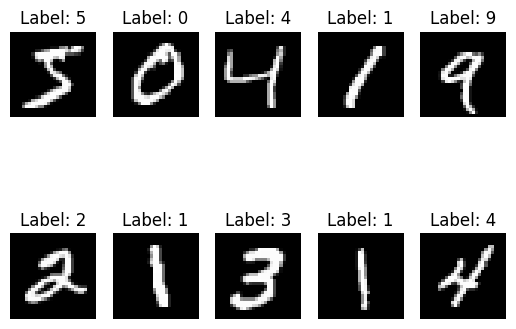

In [5]:
# As a sanity check let's print out one of the training images with its label:

%matplotlib inline
import matplotlib.pyplot as plt 
# This line is used in Jupyter notebooks to enable inline plotting, 
# meaning that plots will be displayed directly below the code cells instead of in a separate window.
# It is not necessary in a standalone script, but it is useful for interactive data exploration and visualization.  
# Plotting the first 10 images in the training set
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {mnist_train_labels[i]}')
    plt.axis('off')


# 4). Set up Convolutional Neural Network 

Step1: We'll start with a 2D convolution of the image - it's set up to take 32 windows, or "filters", of each image, each filter being 3x3 in size.

Step2: We then run a second convolution on top of that with 64 3x3 windows - this topology is just what comes recommended within Keras's own examples. Again you want to re-use previous research whenever possible while tuning CNN's, as it is hard to do.

Step3: Next we apply a MaxPooling2D layer that takes the maximum of each 2x2 result to distill the results down into something more manageable.

Step4: Next we flatten the 2D layer we have at this stage into a 1D layer. 
So at this point we can just pretend we have a traditional multi-layer perceptron...... 

Step5: Now feed that into a hidden, flat layer of 128 units.

Step6: And finally, we feed that into our final 10 units where softmax is applied to choose our category of 0-9.

In [6]:
def MakeMyModel():
    
    model = Sequential()

    # This code initializes a Sequential model, which is a linear stack of layers in Keras.
    # The Sequential model is a simple way to build neural networks layer by layer, 
    # where each layer has exactly one input tensor and one output tensor.

    # Step1: # The first layer is a Conv2D layer, which applies convolutional filters to the input images, 32 3x3 kernels, ReLU activation
    model.add(Conv2D(32, kernel_size=(3, 3),
                    activation='relu',
                    input_shape=input_shape))

    #Step2: 64 3x3 kernels
    model.add(Conv2D(64, (3, 3), activation='relu'))

    # Step3: Reduce by taking the max of each 2x2 block
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Step4: Flatten the results to one dimension for passing into our final layer
    model.add(Flatten())

    # Step5: A hidden layer to learn with
    model.add(Dense(128, activation='relu'))

    # Step6: Final categorization from 0-9 with softmax
    model.add(Dense(10, activation='softmax'))

    return model

model = MakeMyModel()

# Code Explaination 
# This code builds a convolutional neural network (CNN) model using Keras' Sequential API, 
# which is well-suited for image classification tasks like recognizing handwritten digits from the MNIST dataset.

# The model starts with a Conv2D layer that applies 32 filters of size 3x3 to the input images, using the ReLU activation function. 
# This layer extracts basic features such as edges from the images. 
# The input_shape parameter defines the shape of the input data, which should match the preprocessed image dimensions.

# A second Conv2D layer follows, this time with 64 filters of size 3x3 and ReLU activation. 
# Stacking convolutional layers allows the network to learn more complex patterns by combining features detected in earlier layers.

# Next, a MaxPooling2D layer with a pool size of 2x2 reduces the spatial dimensions of the feature maps. 
# This downsampling step helps to decrease computational requirements and makes the learned features more robust to small translations in the input.

# The Flatten layer then converts the 2D feature maps into a 1D vector, 
# preparing the data for the fully connected (dense) layers that follow.

# A Dense layer with 128 neurons and ReLU activation acts as a hidden layer,
# enabling the model to learn higher-level representations from the extracted features.

# Finally, the output layer is another Dense layer with 10 neurons and a softmax activation function. 
# This layer outputs a probability distribution over the 10 possible digit classes, 
# allowing the model to make a final classification decision

# Now check the model description
model.summary()

c:\Users\Arun.Manglick\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

# 5). Compile, Train the Model

In [7]:

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# This code compiles the model with the Adam optimizer, categorical crossentropy loss function, and accuracy as a metric.
# The compile() method configures the model for training.
    # Optimizer: Adam - An adaptive learning rate optimization algorithm that combines the advantages of two other popular optimizers: AdaGrad and RMSProp.
    # Loss Function: Categorical Crossentropy - Used for multi-class classification problems, measures the dissimilarity between the true labels and predicted probabilities.   
    # Metrics: Accuracy - Measures the proportion of correct predictions made by the model during training and evaluation.
    # Note: The optimizer, loss function, and metrics can be adjusted based on the specific problem and dataset.

# Now we can train our model
history = model.fit(train_images, train_labels,
                    batch_size=128,
                    epochs=10,
                    verbose=1,
                    validation_data=(test_images, test_labels))
# This code trains the model using the training images and labels, specifying a batch size of 128 and running for 10 epochs.
# The fit() method is used to train the model on the provided data.
    # train_images: The input images for training.
    # train_labels: The corresponding labels for the training images.
    # batch_size: The number of samples per gradient update. A smaller batch size can lead to more frequent updates, while a larger batch size can stabilize the training process.
    # epochs: The number of times the entire training dataset will be passed through the model during training.
    # verbose: Controls the verbosity of the output during training. 1 means progress bar and metrics will be displayed.
    # validation_data: A tuple containing validation images and labels, used to evaluate the model's performance on unseen data after each epoch.


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 170ms/step - accuracy: 0.8816 - loss: 0.3893 - val_accuracy: 0.9843 - val_loss: 0.0478
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 155ms/step - accuracy: 0.9862 - loss: 0.0468 - val_accuracy: 0.9854 - val_loss: 0.0440
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9889 - val_loss: 0.0364
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - accuracy: 0.9947 - loss: 0.0181 - val_accuracy: 0.9880 - val_loss: 0.0342
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 132ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.9871 - val_loss: 0.0374
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9970 - loss: 0.0090 - val_accuracy: 0.9899 - val_loss: 0.0360
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - accuracy: 0.9980 - loss: 0.0062 - val_accuracy: 0.9897 - val_loss: 0.0383
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.9974 - loss: 0

So here you see, test data accuracy is overfitting in comparision to validation data. 
Test Data accruacy has reached almost 99.88% where as 
Validation Data accurancy is maxed to 98.97%

To prevent overfitting, regularization is required (Dropout or Early Stopping).

- Dropout
    - Dropout work by "dropping out" neurons on each pass to force learing to spread itselff out the network as a whole
    - Dropout regularization forces the learning to be spread out amongst the artificial neurons, further preventing overfitting.
    - Dropout randomly deactivates a subset of neurons during training, which helps in preventing the network from becoming too dependent on any single neuron and thus reduces overfitting.
    - Dropout layers force the network to spread out its learning throughout the network, and can prevent overfitting resulting from learning concentrating in one spot
    
- Early Stopping
    - Prevents eural networks from training too far, and learning patterns in the training data that can't be generalized
    - Halts training when performance on a validation set stops improving, preventing overfitting by not allowing the model to learn noise in the training data

# 6). Repeat Step#4 with Additionally Dropout Layer

In [8]:
# Here we are applying 'Dropping' to our model to reduce overfitting
def MakeMyModelWithDropOut():

    model = Sequential()

    # This code initializes a Sequential model, which is a linear stack of layers in Keras.
    # The Sequential model is a simple way to build neural networks layer by layer, 
    # where each layer has exactly one input tensor and one output tensor.

    # Step1: # The first layer is a Conv2D layer, which applies convolutional filters to the input images, 32 3x3 kernels, ReLU activation
    model.add(Conv2D(32, kernel_size=(3, 3),
                    activation='relu',
                    input_shape=input_shape))

    #Step2: 64 3x3 kernels
    model.add(Conv2D(64, (3, 3), activation='relu'))

    # Step3: Reduce by taking the max of each 2x2 block
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Step4: Flatten the results to one dimension for passing into our final layer
    model.add(Flatten())

    # Step5: A hidden layer to learn with
    model.add(Dense(128, activation='relu'))

    # Step5.1: Adding Dropout to reduce overfitting
    model.add(Dropout(0.5))  # Dropout layer with a dropout rate of 50%

    # Step6: Final categorization from 0-9 with softmax
    model.add(Dense(10, activation='softmax'))

    return model

model_with_dropout = MakeMyModelWithDropOut()





# 7). Re-Compile, Train the Model

In [9]:
# Compile the model again
model_with_dropout.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Train the model with dropout
history_dropout = model_with_dropout.fit(train_images, train_labels,
                            batch_size=128,
                            epochs=10,
                            verbose=1,
                            validation_data=(test_images, test_labels)) 

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 133ms/step - accuracy: 0.8477 - loss: 0.4712 - val_accuracy: 0.9813 - val_loss: 0.0574
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9723 - loss: 0.0931 - val_accuracy: 0.9876 - val_loss: 0.0399
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - accuracy: 0.9814 - loss: 0.0605 - val_accuracy: 0.9877 - val_loss: 0.0362
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - accuracy: 0.9845 - loss: 0.0482 - val_accuracy: 0.9895 - val_loss: 0.0323
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 150ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9911 - val_loss: 0.0280
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy: 0.9917 - val_loss: 0.0266
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9917 - val_loss: 0.0275
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 88s 186ms/step - accuracy: 0.9905 - loss: 0

So here you see after Dropping Layer Regularization, Test Data (99.37%) and Validation Data (99.18%)  accuracy is almost fitting

# 8). Explore effect the 'Batch Size' creates (Local Minima)

Let's increase batch size from 32 to 1000

In [10]:
model_with_dropout_high_batch_size = MakeMyModelWithDropOut()

# Compile the model again
model_with_dropout_high_batch_size.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Train the model with dropout
history_dropout = model_with_dropout_high_batch_size.fit(train_images, train_labels,
                            batch_size=1000,
                            epochs=10,
                            verbose=1,
                            validation_data=(test_images, test_labels)) 

c:\Users\Arun.Manglick\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6969 - loss: 1.0020 - val_accuracy: 0.9607 - val_loss: 0.1296
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9518 - loss: 0.1656 - val_accuracy: 0.9805 - val_loss: 0.0626
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9719 - loss: 0.0963 - val_accuracy: 0.9838 - val_loss: 0.0465
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9785 - loss: 0.0730 - val_accuracy: 0.9872 - val_loss: 0.0381
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9821 - loss: 0.0590 - val_accuracy: 0.9872 - val_loss: 0.0358
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9852 - loss: 0.0478 - val_accuracy: 0.9881 - val_loss: 0.0330
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9860 - loss: 0.0450 - val_accuracy: 0.9888 - val_loss: 0.0317
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9878 - loss: 0.0404 - val_accuracy: 0.9896 - val_loss:

So this time you'll see an opposite pattern. 
I.e. Test Data accuracy is under fitting in comparision to validation data. 
Test Data accruacy has lower to 98.85% where as 
Validation Data accurancy is increased to 99.06%

Now if you run this block a few times, you'll probably get very different results.

Thus you see, Batch sizes that are too large can end up getting stuck in the wrong solution.
The increased batch size caused the optimization algorithm to converge to suboptimal 'local minima'

Note: Increasing the batch size can lead to smoother updates and potentially less noisy gradients, which might sound beneficial but can actually cause the optimization process to miss narrower paths that could lead to better minima. This option correctly identifies a nuanced aspect of how batch size affects the training process, especially in complex loss landscapes common in deep learning

Therefore soluiton is Small Batch Size.
Note: Smaller batch sizes can work their way out of “local minima” more easily

Note: Smaller batch sizes also have a regularization effect. Sometimes you'll get lucky and the large batch will converge on a good solution; other times, not so much.


# 9). Explore effect the 'Learning Rate' 

 The default learning rate for Adam is 0.001; let's see what happens if we increase it by an order of magnitude to 0.01"=

In [ ]:
model_with_dropout_normal_batch_size_high_learningrate = MakeMyModelWithDropOut()

# Adjust the learning rate to a higher value
adjusted_learning_rate = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

# Compile the model again
model_with_dropout_normal_batch_size_high_learningrate.compile(optimizer=adjusted_learning_rate,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with dropout
history_dropout = model_with_dropout_normal_batch_size_high_learningrate.fit(train_images, train_labels,
                            batch_size=128,
                            epochs=10,
                            verbose=1,
                            validation_data=(test_images, test_labels)) 

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 137ms/step - accuracy: 0.8522 - loss: 0.4772 - val_accuracy: 0.9807 - val_loss: 0.0599
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9056s 19s/step - accuracy: 0.9699 - loss: 0.1032 - val_accuracy: 0.9842 - val_loss: 0.0506
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39707s 85s/step - accuracy: 0.9752 - loss: 0.0797 - val_accuracy: 0.9880 - val_loss: 0.0402
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - accuracy: 0.9779 - loss: 0.0705 - val_accuracy: 0.9859 - val_loss: 0.0473
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - accuracy: 0.9788 - loss: 0.0698 - val_accuracy: 0.9872 - val_loss: 0.0423
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9806 - loss: 0.0653 - val_accuracy: 0.9875 - val_loss: 0.0433
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9821 - loss: 0.0611 - val_accuracy: 0.9852 - val_loss: 0.0526
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9827 - loss: 0.0

: 

This time more terrible, effect on the results. 

So this time you'll see an opposite pattern. 
I.e. Test Data accuracy is further under fitting in comparision to validation data. 
Test Data accruacy has lower to ~95% where as 
Validation Data accurancy is reduced to ~98%

Summary: Small batch sizes are best paired with low learning rates, and large learning rates have a tendency to overshoot the correct solution entirely - which is probably what happened here. 

The learning rate is an example of a hyperparameter that you might want to tune by just trying different values.